In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import MultipleLocator, MaxNLocator

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


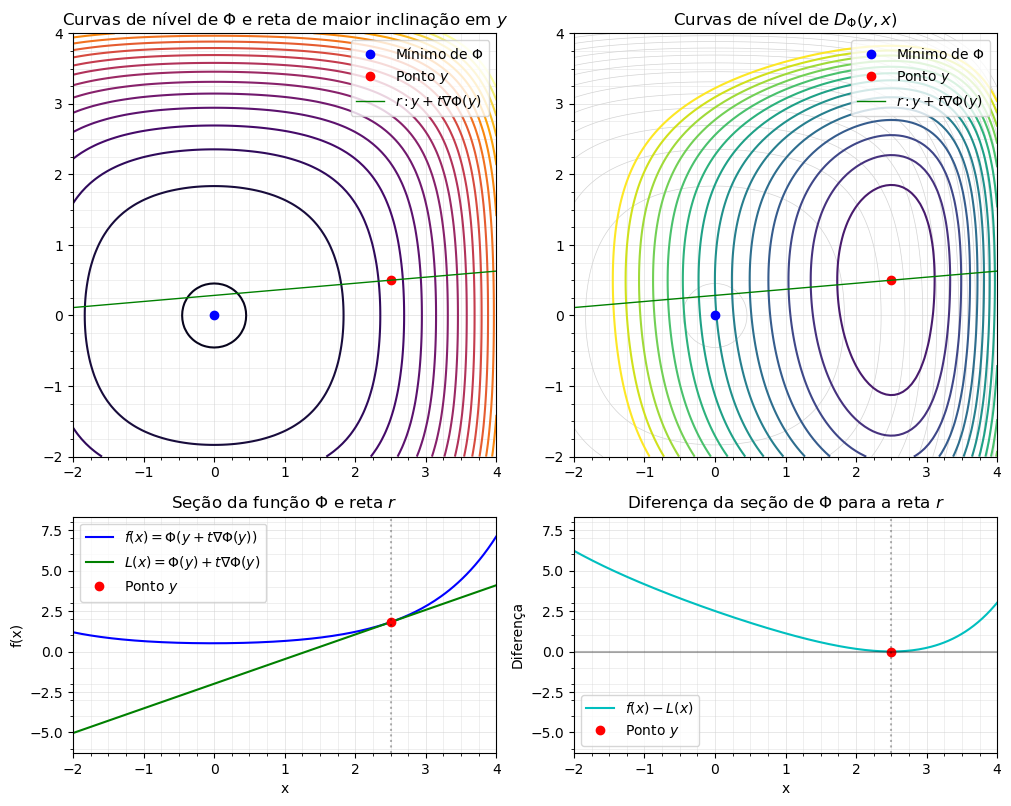

In [2]:
# Configuração geral
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=2, ncols=2, width_ratios=[1, 1], height_ratios=[2, 1])

# Funções matemáticas (mantidas as mesmas)
def phi(x, y):
    return (x-1)**2 + 2*(y-1)**2

def grad_phi(x, y):
    return np.array([2*(x-1), 4*(y-1)])

a = 1
b = 1
c = 1.5

def phi(x,y):
    return a * x**2 + b * y**2 +  c * x * y

def grad_phi(x,y):
    return np.array([2 * a * x + c * y, 2 * b * y + c* x])

def D_phi(y, x):
    return phi(x[0], x[1]) - phi(y[0], y[1]) - np.dot(grad_phi(y[0], y[1]), x - y)

def phi(x,y):
    return (np.exp(x) + np.exp(-x) + np.exp(y) + np.exp(-y))*0.125

def grad_phi(x,y):
    return 0.125 * np.array([np.exp(x) - np.exp(-x), np.exp(y) - np.exp(-y)])

# Pontos importantes
x_min, y_min = 0, 0
x_y, y_y = 2.5, 0.5
y_point = np.array([x_y, y_y])

# Grade para plotagem
x = np.linspace(-2, 4, 100)
y = np.linspace(-2, 4, 100)
X, Y = np.meshgrid(x, y)
Z = phi(X, Y)

# Reta r
grad_y = grad_phi(x_y, y_y)
m_r = grad_y[1]/grad_y[0] if grad_y[0] != 0 else np.nan
b_r = y_y - m_r*x_y if grad_y[0] != 0 else np.nan
reta_r = lambda x: m_r*x + b_r if grad_y[0] != 0 else np.full_like(x, np.nan)

### Configurações do grid mais denso ###
grid_params = {
    'alpha': 0.75,
    'linestyle': '-',
    'linewidth': 0.5,
    'color': 'lightgray'
}

# Espaçamento mais denso para os ticks
minor_locator = MultipleLocator(0.25)
major_locator = MultipleLocator(1)

### Primeiro plot ###
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_xlim(-2, 4)
ax1.set_ylim(-2, 4)
ax1.set_aspect('equal')
ax1.set_title(r'Curvas de nível de $\Phi$ e reta de maior inclinação em $y$')

ax1.xaxis.set_major_locator(major_locator)
ax1.yaxis.set_major_locator(major_locator)
ax1.xaxis.set_minor_locator(minor_locator)
ax1.yaxis.set_minor_locator(minor_locator)
ax1.grid(which='major', **grid_params)
ax1.grid(which='minor', **{**grid_params, 'alpha': 0.5})

contour = ax1.contour(X, Y, Z, levels=np.linspace(0, 10, 20), cmap='inferno')
ax1.plot(x_min, y_min, 'bo', label=r'Mínimo de $\Phi$')
ax1.plot(x_y, y_y, 'ro', label=r'Ponto $y$')
ax1.plot(x, reta_r(x), 'g-', linewidth=1, label=r'$r: y + t \nabla \Phi(y)$')
ax1.legend()

### Segundo plot ###
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_xlim(-2, 4)
ax2.set_ylim(-2, 4)
ax2.set_aspect('equal')
ax2.set_title(r'Curvas de nível de $D_\Phi(y,x)$')

ax2.xaxis.set_major_locator(major_locator)
ax2.yaxis.set_major_locator(major_locator)
ax2.xaxis.set_minor_locator(minor_locator)
ax2.yaxis.set_minor_locator(minor_locator)
ax2.grid(which='major', **grid_params)
ax2.grid(which='minor', **{**grid_params, 'alpha': 0.5})

D = np.array([[D_phi(y_point, np.array([X[i,j], Y[i,j]])) 
              for j in range(X.shape[1])] for i in range(X.shape[0])])

ax2.contour(X, Y, Z, levels=np.linspace(0, 10, 20), colors='lightgray', linewidths=0.5)
contour_D = ax2.contour(X, Y, D, levels=np.linspace(0, 5, 15), cmap=cm.viridis, linewidths=1.5)
ax2.plot(x_min, y_min, 'bo', label=r'Mínimo de $\Phi$')
ax2.plot(x_y, y_y, 'ro', label=r'Ponto $y$')
ax2.plot(x, reta_r(x), 'g-', linewidth=1, label=r'$r: y + t \nabla \Phi(y)$')
ax2.legend()

### Terceiro plot ###
ax3 = fig.add_subplot(gs[1, 0])
f = lambda x: phi(x, reta_r(x))
grad = grad_phi(x_y, y_y) 
delta_y = grad[1]/grad[0]
reta_tangente = lambda x: phi(x_y, y_y) + grad[0]*(x - x_y) + grad[1]*(reta_r(x)-y_y)

x_vals = np.linspace(-2, 4, 200)
f_vals = f(x_vals)
tangente_vals = reta_tangente(x_vals)

# Calcular limites comuns para os eixos y dos plots inferiores
y_vals_combined = np.concatenate([f_vals, tangente_vals])
y_min_combined = np.min(y_vals_combined)
y_max_combined = np.max(y_vals_combined)
y_range_combined = y_max_combined - y_min_combined

# Aplicar os mesmos limites para ax3 e ax4
margin = 0.1 * y_range_combined
common_ylim = (y_min_combined - margin, y_max_combined + margin)

ax3.set_xlim(-2, 4)
ax3.set_ylim(common_ylim)
ax3.set_xlabel('x')
ax3.set_ylabel('f(x)')
ax3.set_title(r'Seção da função $\Phi$ e reta $r$')

ax3.xaxis.set_major_locator(MultipleLocator(1))
ax3.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax3.xaxis.set_minor_locator(MultipleLocator(0.25))
ax3.yaxis.set_minor_locator(MultipleLocator(1))

ax3.grid(which='major', **grid_params)
ax3.grid(which='minor', **{**grid_params, 'alpha': 0.5})

ax3.plot(x_vals, f_vals, 'b-', label=r'$f(x) = \Phi(y + t\nabla \Phi(y))$')
ax3.plot(x_vals, tangente_vals, 'g-', label=r'$L(x) = \Phi(y) + t\nabla \Phi(y)$')
ax3.plot(x_y, f(x_y), 'ro', label=r'Ponto $y$')
ax3.axvline(x=x_y, color='k', linestyle=':', alpha=0.3)
ax3.legend()

### Quarto plot ###
ax4 = fig.add_subplot(gs[1, 1])
diferenca = f_vals - tangente_vals

# Usar os mesmos limites do eixo y que ax3
ax4.set_xlim(-2, 4)
ax4.set_ylim(common_ylim)  # Mesma escala que ax3
ax4.set_xlabel('x')
ax4.set_ylabel('Diferença')
ax4.set_title(r'Diferença da seção de $\Phi$ para a reta $r$')

ax4.xaxis.set_major_locator(MultipleLocator(1))
ax4.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax4.xaxis.set_minor_locator(MultipleLocator(0.25))
ax4.yaxis.set_minor_locator(MultipleLocator(1))

ax4.grid(which='major', **grid_params)
ax4.grid(which='minor', **{**grid_params, 'alpha': 0.5})

ax4.plot(x_vals, diferenca, 'c-', label=r'$f(x) - L(x)$')
ax4.plot(x_y, 0, 'ro', label=r'Ponto $y$')
ax4.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax4.axvline(x=x_y, color='k', linestyle=':', alpha=0.3)
ax4.legend()

plt.show()
caminho_arquivo = f"imagens_dissertação/bregman_divergence_and_projection/Bregman_Divergence_4_plots.pdf"
fig.savefig(caminho_arquivo, bbox_inches="tight")

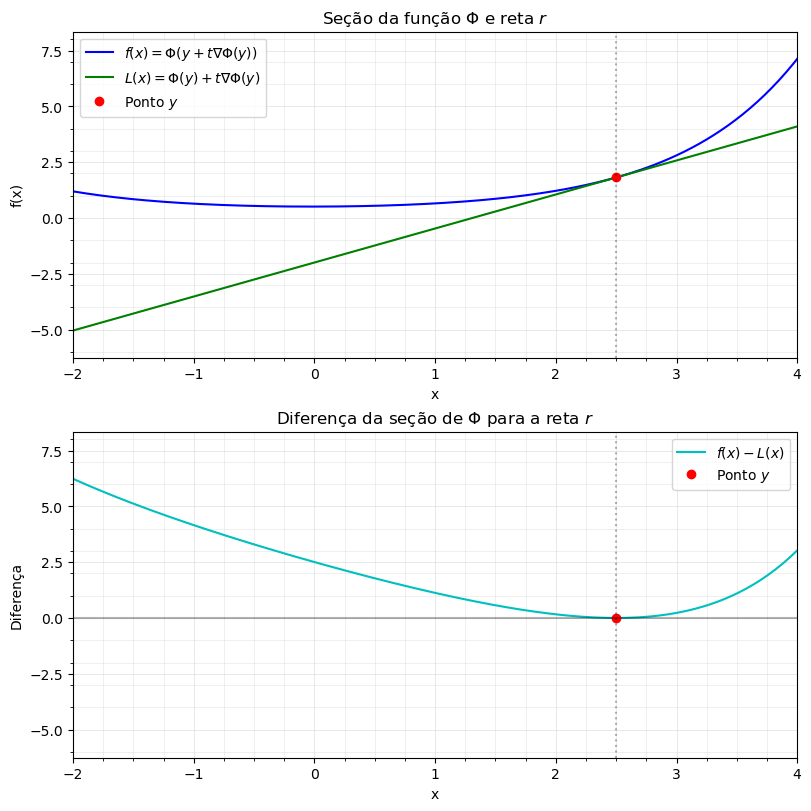

In [3]:
# Configuração geral
fig = plt.figure(figsize=(8, 8), constrained_layout=True)  # Ajustado para 2 linhas e 1 coluna
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 1])  # Duas linhas e uma coluna

# Funções matemáticas
def phi(x, y):
    return (x-1)**2 + 2*(y-1)**2

def grad_phi(x, y):
    return np.array([2*(x-1), 4*(y-1)])

a = 1
b = 1
c = 1.5

def phi(x,y):
    return a * x**2 + b * y**2 +  c * x * y

def grad_phi(x,y):
    return np.array([2 * a * x + c * y, 2 * b * y + c* x])

def D_phi(y, x):
    return phi(x[0], x[1]) - phi(y[0], y[1]) - np.dot(grad_phi(y[0], y[1]), x - y)

def phi(x,y):
    return (np.exp(x) + np.exp(-x) + np.exp(y) + np.exp(-y))*0.125

def grad_phi(x,y):
    return 0.125 * np.array([np.exp(x) - np.exp(-x), np.exp(y) - np.exp(-y)])

# Pontos importantes
x_min, y_min = 0, 0
x_y, y_y = 2.5, 0.5
y_point = np.array([x_y, y_y])

# Grade para plotagem
x = np.linspace(-2, 4, 100)
y = np.linspace(-2, 4, 100)
X, Y = np.meshgrid(x, y)
Z = phi(X, Y)

# Reta r
grad_y = grad_phi(x_y, y_y)
m_r = grad_y[1]/grad_y[0] if grad_y[0] != 0 else np.nan
b_r = y_y - m_r*x_y if grad_y[0] != 0 else np.nan
reta_r = lambda x: m_r*x + b_r if grad_y[0] != 0 else np.full_like(x, np.nan)

### Configurações do grid mais denso ###
grid_params = {
    'alpha': 0.75,           # Mais transparente
    'linestyle': '-',        # Linha contínua fina
    'linewidth': 0.5,        # Mais fina ainda
    'color': 'lightgray'     # Cor mais clara
}

### Terceiro plot ###
ax3 = fig.add_subplot(gs[0, 0])
f = lambda x: phi(x, reta_r(x))
grad = grad_phi(x_y, y_y) 
delta_y = grad[1]/grad[0]
reta_tangente = lambda x: phi(x_y, y_y) + grad[0]*(x - x_y) + grad[1]*(reta_r(x)-y_y)

x_vals = np.linspace(-2, 4, 200)
f_vals = f(x_vals)
tangente_vals = reta_tangente(x_vals)

# Calcular limites comuns para os eixos y dos plots inferiores
y_vals_combined = np.concatenate([f_vals, tangente_vals])
y_min_combined = np.min(y_vals_combined)
y_max_combined = np.max(y_vals_combined)
y_range_combined = y_max_combined - y_min_combined

# Aplicar os mesmos limites para ax3 e ax4
margin = 0.1 * y_range_combined
common_ylim = (y_min_combined - margin, y_max_combined + margin)

ax3.set_xlim(-2, 4)
ax3.set_ylim(common_ylim)
ax3.set_xlabel('x')
ax3.set_ylabel('f(x)')
ax3.set_title(r'Seção da função $\Phi$ e reta $r$')

ax3.xaxis.set_major_locator(MultipleLocator(1))
ax3.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax3.xaxis.set_minor_locator(MultipleLocator(0.25))
ax3.yaxis.set_minor_locator(MultipleLocator(1))

ax3.grid(which='major', **grid_params)
ax3.grid(which='minor', **{**grid_params, 'alpha': 0.5})

ax3.plot(x_vals, f_vals, 'b-', label=r'$f(x) = \Phi(y + t\nabla \Phi(y))$')
ax3.plot(x_vals, tangente_vals, 'g-', label=r'$L(x) = \Phi(y) + t\nabla \Phi(y)$')
ax3.plot(x_y, f(x_y), 'ro', label=r'Ponto $y$')
ax3.axvline(x=x_y, color='k', linestyle=':', alpha=0.3)
ax3.legend()

### Quarto plot ###
ax4 = fig.add_subplot(gs[1, 0])
diferenca = f_vals - tangente_vals

# Usar os mesmos limites do eixo y que ax3
ax4.set_xlim(-2, 4)
ax4.set_ylim(common_ylim)  # Mesma escala que ax3
ax4.set_xlabel('x')
ax4.set_ylabel('Diferença')
ax4.set_title(r'Diferença da seção de $\Phi$ para a reta $r$')

ax4.xaxis.set_major_locator(MultipleLocator(1))
ax4.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax4.xaxis.set_minor_locator(MultipleLocator(0.25))
ax4.yaxis.set_minor_locator(MultipleLocator(1))

ax4.grid(which='major', **grid_params)
ax4.grid(which='minor', **{**grid_params, 'alpha': 0.5})

ax4.plot(x_vals, diferenca, 'c-', label=r'$f(x) - L(x)$')
ax4.plot(x_y, 0, 'ro', label=r'Ponto $y$')
ax4.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax4.axvline(x=x_y, color='k', linestyle=':', alpha=0.3)
ax4.legend()

plt.show()
caminho_arquivo = f"imagens_dissertação/bregman_divergence_and_projection/Bregman_Divergence_plots_3_e_4.pdf"
fig.savefig(caminho_arquivo, bbox_inches="tight")

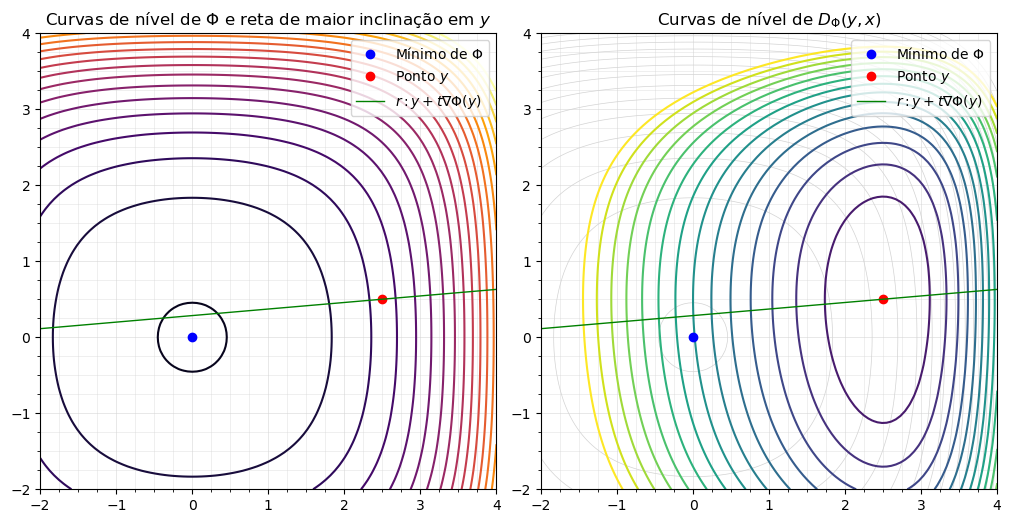

In [4]:
# Configuração geral
fig = plt.figure(figsize=(10, 5), constrained_layout=True)  # Ajustado para 1 linha e 2 colunas
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1, 1])  # Apenas uma linha com duas colunas

# Funções matemáticas
def phi(x, y):
    return (x-1)**2 + 2*(y-1)**2

def grad_phi(x, y):
    return np.array([2*(x-1), 4*(y-1)])

a = 1
b = 1
c = 1.5

def phi(x,y):
    return a * x**2 + b * y**2 +  c * x * y

def grad_phi(x,y):
    return np.array([2 * a * x + c * y, 2 * b * y + c* x])

def D_phi(y, x):
    return phi(x[0], x[1]) - phi(y[0], y[1]) - np.dot(grad_phi(y[0], y[1]), x - y)

def phi(x,y):
    return (np.exp(x) + np.exp(-x) + np.exp(y) + np.exp(-y))*0.125

def grad_phi(x,y):
    return 0.125 * np.array([np.exp(x) - np.exp(-x), np.exp(y) - np.exp(-y)])

# Pontos importantes
x_min, y_min = 0, 0
x_y, y_y = 2.5, 0.5
y_point = np.array([x_y, y_y])

# Grade para plotagem
x = np.linspace(-2, 4, 100)
y = np.linspace(-2, 4, 100)
X, Y = np.meshgrid(x, y)
Z = phi(X, Y)

# Reta r
grad_y = grad_phi(x_y, y_y)
m_r = grad_y[1]/grad_y[0] if grad_y[0] != 0 else np.nan
b_r = y_y - m_r*x_y if grad_y[0] != 0 else np.nan
reta_r = lambda x: m_r*x + b_r if grad_y[0] != 0 else np.full_like(x, np.nan)

### Configurações do grid mais denso ###
grid_params = {
    'alpha': 0.75,           # Mais transparente
    'linestyle': '-',        # Linha contínua fina
    'linewidth': 0.5,        # Mais fina ainda
    'color': 'lightgray'     # Cor mais clara
}

# Espaçamento mais denso para os ticks
minor_locator = MultipleLocator(0.25)  # Quadriculado a cada 0.5 unidade
major_locator = MultipleLocator(1)    # Ticks principais a cada 1 unidade

### Primeiro plot ###-----------------------------------------------------------------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_xlim(-2, 4)
ax1.set_ylim(-2, 4)
ax1.set_aspect('equal')
ax1.set_title(r'Curvas de nível de $\Phi$ e reta de maior inclinação em $y$')

# Configuração do grid denso
ax1.xaxis.set_major_locator(major_locator)
ax1.yaxis.set_major_locator(major_locator)
ax1.xaxis.set_minor_locator(minor_locator)
ax1.yaxis.set_minor_locator(minor_locator)
ax1.grid(which='major', **grid_params)
ax1.grid(which='minor', **{**grid_params, 'alpha': 0.5})  # Grid menor ainda mais suave

contour = ax1.contour(X, Y, Z, levels=np.linspace(0, 10, 20), cmap='inferno')
#ax1.clabel(contour, inline=True, fontsize=8)
ax1.plot(x_min, y_min, 'bo', label=r'Mínimo de $\Phi$')
ax1.plot(x_y, y_y, 'ro', label=r'Ponto $y$')
ax1.plot(x, reta_r(x), 'g-', linewidth=1, label=r'$r: y + t\nabla \Phi(y)$')
ax1.legend()

### Segundo plot ###------------------------------------------------------------------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_xlim(-2, 4)
ax2.set_ylim(-2, 4)
ax2.set_aspect('equal')
ax2.set_title(r'Curvas de nível de $D_\Phi(y,x)$')

# Aplicando o mesmo grid denso
ax2.xaxis.set_major_locator(major_locator)
ax2.yaxis.set_major_locator(major_locator)
ax2.xaxis.set_minor_locator(minor_locator)
ax2.yaxis.set_minor_locator(minor_locator)
ax2.grid(which='major', **grid_params)
ax2.grid(which='minor', **{**grid_params, 'alpha': 0.5})  # Grid menor ainda mais suave

D = np.array([[D_phi(y_point, np.array([X[i,j], Y[i,j]])) 
              for j in range(X.shape[1])] for i in range(X.shape[0])])

ax2.contour(X, Y, Z, levels=np.linspace(0, 10, 20), colors='lightgray', linewidths=0.5)
contour_D = ax2.contour(X, Y, D, levels=np.linspace(0, 5, 15), cmap=cm.viridis, linewidths=1.5)
#ax2.clabel(contour_D, inline=True, fontsize=8)
ax2.plot(x_min, y_min, 'bo', label=r'Mínimo de $\Phi$')
ax2.plot(x_y, y_y, 'ro', label=r'Ponto $y$')
ax2.plot(x, reta_r(x), 'g-', linewidth=1, label=r'$r: y + t\nabla \Phi(y)$')
ax2.legend()

plt.show()
caminho_arquivo = f"imagens_dissertação/bregman_divergence_and_projection/Bregman_Divergence_plots_1_e_2.pdf"
fig.savefig(caminho_arquivo, bbox_inches="tight")

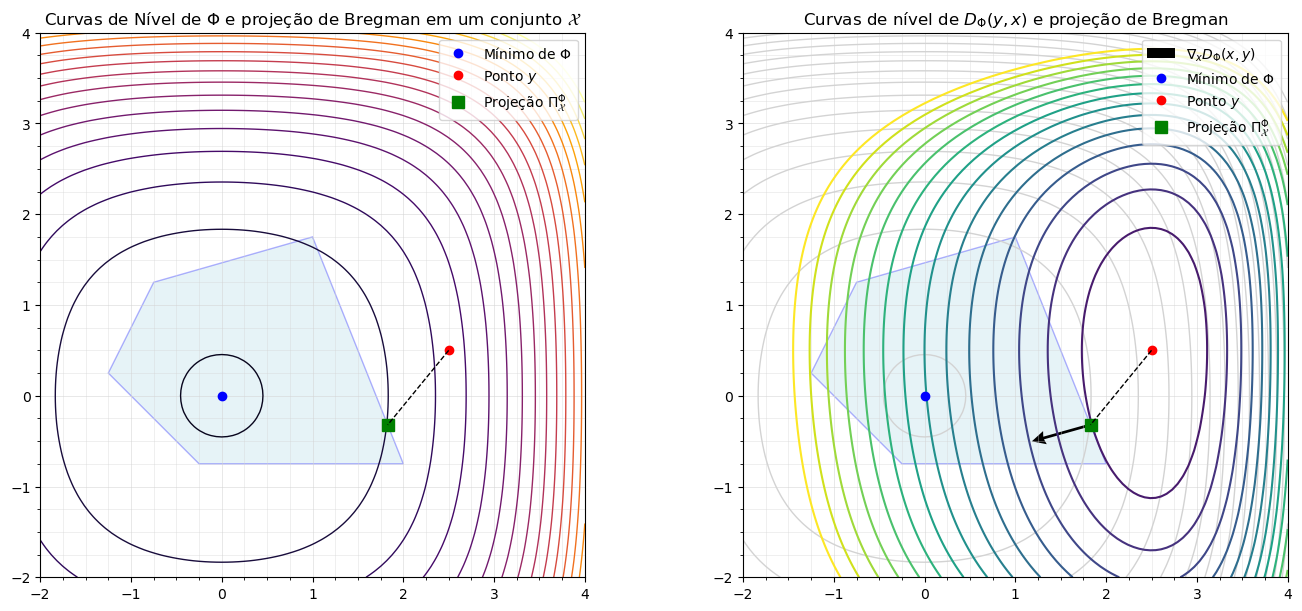

In [5]:
# Configuração geral
fig = plt.figure(figsize=(14, 6), constrained_layout=True)
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1, 1])

# 1. Definir o pentágono convexo X (deslocado para cima/esquerda)
#vertices = np.array([[-0.5, 0.5], [1.5, 1], [1, 3], [-1, 2.5], [-1.5, 1.5]]) + np.array([0.25,-1.25])
vertices = np.array([[-0.5, 0.5], [1.75, 0.5], [0.75, 3], [-1, 2.5], [-1.5, 1.5]]) + np.array([0.25,-1.25])
X_poly = np.vstack([vertices, vertices[0]])

def in_X(x, y):
    path = plt.Path(vertices)
    return path.contains_points(np.column_stack([x.ravel(), y.ravel()])).reshape(x.shape)

# 2. Gerar pontos do bordo
bordo = []
for i in range(len(vertices)):
    start = vertices[i]
    end = vertices[(i+1)%len(vertices)]
    bordo.append(np.column_stack([
        np.linspace(start[0], end[0], 100),
        np.linspace(start[1], end[1], 100)
    ]))
X_bordo = np.vstack(bordo)

# 3. Ponto y (mantido como solicitado)
x_y, y_y = 2.5, 0.5
y_point = np.array([x_y, y_y])

# 4. Projeção de Bregman
def bregman_projection(y, bordo_points):
    dists = np.array([D_phi(p,y) for p in bordo_points])
    return bordo_points[np.argmin(dists)]

proj = bregman_projection(y_point, X_bordo)

### Configurações do grid mais denso ###
grid_params = {
    'alpha': 0.75,
    'linestyle': '-',
    'linewidth': 0.5,
    'color': 'lightgray'
}

# Espaçamento mais denso para os ticks
minor_locator = MultipleLocator(0.25)
major_locator = MultipleLocator(1)

### Primeiro Gráfico ###
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_xlim(-2, 4)
ax1.set_ylim(-2, 4)
ax1.set_aspect('equal')
ax1.set_title(r'Curvas de Nível de $\Phi$ e projeção de Bregman em um conjunto $\mathcal{X}$')

# Configuração do grid denso
ax1.xaxis.set_major_locator(major_locator)
ax1.yaxis.set_major_locator(major_locator)
ax1.xaxis.set_minor_locator(minor_locator)
ax1.yaxis.set_minor_locator(minor_locator)
ax1.grid(which='major', **grid_params)
ax1.grid(which='minor', **{**grid_params, 'alpha': 0.5})

# Pentágono X
ax1.fill(X_poly[:,0], X_poly[:,1], 'lightblue', alpha=0.3, edgecolor='blue', linewidth=1)

# Curvas de nível de φ
contour = ax1.contour(X, Y, Z, levels=np.linspace(0, 10, 20), cmap='inferno', linewidths=1)

# Elementos
ax1.plot(x_min, y_min, 'bo', label=r'Mínimo de $\Phi$')
ax1.plot(x_y, y_y, 'ro', label=r'Ponto $y$')
ax1.plot(proj[0], proj[1], 'gs', markersize=8, label=r'Projeção $\Pi_{\mathcal{X}}^\Phi$')
ax1.plot([x_y, proj[0]], [y_y, proj[1]], 'k--', linewidth=1)
ax1.legend()

### Segundo Gráfico ###
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_xlim(-2, 4)
ax2.set_ylim(-2, 4)
ax2.set_aspect('equal')
ax2.set_title(r'Curvas de nível de $D_\Phi(y,x)$ e projeção de Bregman')

# Configuração do grid denso
ax2.xaxis.set_major_locator(major_locator)
ax2.yaxis.set_major_locator(major_locator)
ax2.xaxis.set_minor_locator(minor_locator)
ax2.yaxis.set_minor_locator(minor_locator)
ax2.grid(which='major', **grid_params)
ax2.grid(which='minor', **{**grid_params, 'alpha': 0.5})

# Pentágono X
ax2.fill(X_poly[:,0], X_poly[:,1], 'lightblue', alpha=0.3, edgecolor='blue', linewidth=1)

# Curvas de nível da divergência
D = np.array([[D_phi(y_point, np.array([X[i,j], Y[i,j]])) 
              for j in range(X.shape[1])] for i in range(X.shape[0])])

ax2.contour(X, Y, Z, levels=np.linspace(0, 10, 20), colors='lightgray', linewidths=1)
contour_D = ax2.contour(X, Y, D, levels=np.linspace(0, 5, 15), cmap=cm.viridis, linewidths=1.5)

# Elementos
vetor_normal = grad_phi(y_point[0],y_point[1]) - grad_phi(proj[0],proj[1])

ax2.quiver(proj[0], proj[1], -vetor_normal[0], -vetor_normal[1], scale = 7, width=0.005, headwidth=5, label=r'$\nabla_xD_\Phi(x,y)$')
ax2.plot(x_min, y_min, 'bo', label=r'Mínimo de $\Phi$')
ax2.plot(x_y, y_y, 'ro', label=r'Ponto $y$')
ax2.plot(proj[0], proj[1], 'gs', markersize=8, label=r'Projeção $\Pi_{\mathcal{X}}^\Phi$')
ax2.plot([x_y, proj[0]], [y_y, proj[1]], 'k--', linewidth=1)
ax2.legend()

plt.show()
caminho_arquivo = f"imagens_dissertação/bregman_divergence_and_projection/Bregman_Projection.pdf"
fig.savefig(caminho_arquivo, bbox_inches="tight")